### 피크치 검출 (Scipy find_peaks())

- 피크(Peak)란? => 가장 높은 값을 의미함.

- find_peaks() 는 두 개의 결과값을 반환한다. => peaks, properties = find_peaks(value)

##### Parameter

- find_peaks()에는 여러 가지 파라미터들이 존재함.

- find_peaks(value, height) => height에 하나의 값이 있다면, 해당 값보다 큰 threshold를 찾는다. [0, 10] 처럼 범위로 설정하여 0~10 사이의 값 중 피크치를 찾는 것도 가능함.

- distance => 서로 인접한 피크치 사이의 최소 수평 거리 (더 작은 피크치가 제거됨.) => 피크의 주기성을 알고 있을 때 매우 유용함. 

##### Returns

- peaks => 해당 조건을 전부 만족하는 Peak값

- properties => 해당 조건에 만족하는 피크의 속성을 반환하는 딕셔너리 형태

> properties['peak_heights'] => 피크치의 높이

> 등등 있음.



그래서 우리는 한 번의 보행을 할 때 주기를 구해, height 파라미터로 최소 treshold 구하고, 

distance로 지정해서 그 distance마다의 피크치를 구하면 무릎이 최대로 들릴 때의 값을 구할 수 있을 것 같음.

하지만 사람마다 보행주기가 다르기 때문에 어캐 찾아야하노,,

<hr>

## Firebase로 데이터 가져오기

In [45]:
# firebase url설정과 비공개 key 세팅

import firebase_admin
from firebase_admin import credentials
from firebase_admin import firestore
from firebase_admin import db

if not firebase_admin._apps:
    cred = credentials.Certificate("gait-analysis-7350b-firebase-adminsdk-czbst-e609643d68.json")
    firebase_admin.initialize_app(cred,{'databaseURL':'https://gait-analysis-7350b-default-rtdb.asia-southeast1.firebasedatabase.app/230128_jihun'})

In [46]:
# firebase로 값 저장, 변경, 가져오기 메서드

import numpy as np
import pandas as pd


#해당 filename에 해당하는 테이블 가져오기.
def getDataName(filename):
    dir = db.reference(filename)
    data = dir.get()
    df = pd.DataFrame(data)
    return df


#getData로 가져온 df를 다른 이름으로 저장하기.
def setData(df):
    dict = {}
    dict.update({'Roll' : df['Roll'].values.tolist()})
    dict.update({'Pitch' : df['Pitch'].values.tolist()})
    dict.update({'Yaw' : df['Yaw'].values.tolist()})
    dict.update({'Time' : df['Time'].values.tolist()})

    name = input()
    new_dir = db.reference(name)
    new_dir.update(dict)
    

#디폴트로 저장되는 테이블 이름 "input"을 df로 가져오기
def getData():    
    dir = db.reference("input") #데이터베이스에 저장되어있는 데이터 이름
    data = dir.get()
    
    dir = db.reference()
    
    data_list = np.concatenate(data).tolist()
    
    for i in range(0,len(data_list)):
        data_list[i] = data_list[i].split(',')
    
    
    df = pd.DataFrame(data_list)
    df.columns = ['Roll','Pitch','Yaw','Time']
    df = df.astype('float') 

    df['Time'] = df['Time'].apply(lambda x: x/1000)
    first_time = df['Time'].loc[0]
    df['Time'] = df['Time'].apply(lambda x: x-first_time)
    
    df = df.loc[200:,:]
    
    return df

<hr>

In [21]:
df_jihun = getDataName("230130_jihun5")
df_minjung = getDataName("230130_minjung2")

<AxesSubplot:>

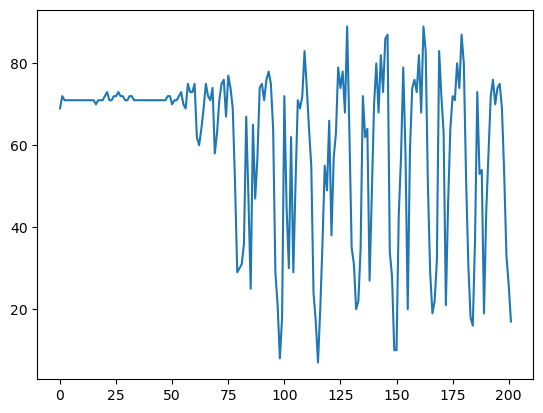

In [22]:
df_jihun['Pitch'].plot()

In [83]:
df_jihun['Roll'].values.tolist()

[-12.0,
 -11.0,
 -12.0,
 -11.0,
 -11.0,
 -12.0,
 -12.0,
 -12.0,
 -12.0,
 -12.0,
 -12.0,
 -12.0,
 -12.0,
 -12.0,
 -11.0,
 -12.0,
 -12.0,
 -12.0,
 -12.0,
 -12.0,
 -11.0,
 -11.0,
 -11.0,
 -11.0,
 -11.0,
 -11.0,
 -11.0,
 -11.0,
 -11.0,
 -11.0,
 -11.0,
 -11.0,
 -11.0,
 -11.0,
 -12.0,
 -12.0,
 -11.0,
 -11.0,
 -12.0,
 -12.0,
 -12.0,
 -12.0,
 -12.0,
 -11.0,
 -12.0,
 -12.0,
 -12.0,
 -12.0,
 -12.0,
 -12.0,
 -12.0,
 -12.0,
 -13.0,
 -13.0,
 -11.0,
 -13.0,
 -14.0,
 -14.0,
 -12.0,
 -16.0,
 -10.0,
 -13.0,
 -20.0,
 -17.0,
 -12.0,
 -13.0,
 -9.0,
 -18.0,
 -6.0,
 1.0,
 -6.0,
 -14.0,
 -5.0,
 -9.0,
 -5.0,
 -12.0,
 -2.0,
 -17.0,
 2.0,
 -23.0,
 -20.0,
 -16.0,
 -9.0,
 -6.0,
 -31.0,
 -5.0,
 -24.0,
 15.0,
 -12.0,
 0.0,
 -12.0,
 -7.0,
 -11.0,
 -12.0,
 -9.0,
 6.0,
 -20.0,
 -13.0,
 -20.0,
 -6.0,
 -4.0,
 -26.0,
 5.0,
 -27.0,
 24.0,
 -12.0,
 -7.0,
 -9.0,
 -8.0,
 -7.0,
 -14.0,
 -11.0,
 0.0,
 -19.0,
 -14.0,
 -23.0,
 -5.0,
 -11.0,
 -30.0,
 -9.0,
 -20.0,
 20.0,
 -4.0,
 -14.0,
 -5.0,
 -5.0,
 -8.0,
 -15.0,
 -1.0,
 -10.0,


In [75]:
from scipy.signal import find_peaks
peaks, _ = find_peaks(df_jihun['Roll'], distance=10)
peaks = peaks.tolist()

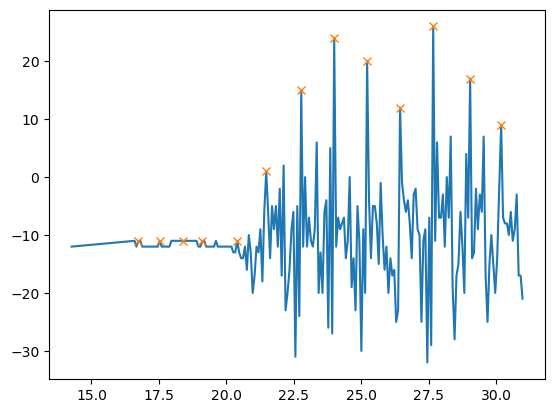

In [80]:
import matplotlib.pyplot as plt

plt.plot(df_jihun['Time'], df_jihun['Roll'])
plt.plot(df_jihun['Time'][peaks], df_jihun['Roll'][peaks], 'x')
plt.show()

In [ ]:
find_peaks(df, thre)